# Day 7 — Baseline Model Training

## Objectives

- Load preprocessed train/test data from Day 6
- Train 3 baseline models:
  - Logistic Regression
  - Random Forest
  - XGBoost
- Evaluate using Accuracy, Precision, Recall, F1-score, and ROC-AUC
- Compare all models
- Select the best baseline model
- Save the best model

In [1]:
import sys
print(sys.executable)

c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\.venv\Scripts\python.exe


In [2]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.2.0


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import json

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
current_directory = Path.cwd()

if (current_directory / "data").exists():
    PROJECT_ROOT = current_directory
elif (current_directory.parent / "data").exists():
    PROJECT_ROOT = current_directory.parent
else:
    raise FileNotFoundError("Could not find project root.")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine


In [7]:
X_train = np.load(PROCESSED_DIR / "X_train_processed.npy")
X_test = np.load(PROCESSED_DIR / "X_test_processed.npy")

y_train = np.load(PROCESSED_DIR / "y_train.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTrain churn rate:", round(y_train.mean(), 3))
print("Test churn rate :", round(y_test.mean(), 3))

X_train shape: (5616, 50)
X_test shape : (1405, 50)
y_train shape: (5616,)
y_test shape : (1405,)

Train churn rate: 0.264
Test churn rate : 0.265


In [8]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained classifier and return classification metrics.
    """

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1_Score": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }

    print(f"\n{'=' * 50}")
    print(f"Results for: {model_name}")
    print(f"{'=' * 50}")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Stayed", "Churned"]
        )
    )

    print(f"ROC-AUC Score: {metrics['ROC_AUC']:.4f}")

    return metrics, y_pred, y_proba

In [9]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train, y_train)

log_reg_metrics, log_reg_pred, log_reg_proba = evaluate_model(
    log_reg,
    X_test,
    y_test,
    "Logistic Regression"
)


Results for: Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1033
     Churned       0.50      0.77      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.79      0.74      0.75      1405

ROC-AUC Score: 0.8399


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_metrics, rf_pred, rf_proba = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)


Results for: Random Forest
              precision    recall  f1-score   support

      Stayed       0.88      0.81      0.84      1033
     Churned       0.57      0.69      0.62       372

    accuracy                           0.78      1405
   macro avg       0.72      0.75      0.73      1405
weighted avg       0.80      0.78      0.79      1405

ROC-AUC Score: 0.8411


In [11]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

scale_pos_weight = neg_count / pos_count

print(f"Negative (stayed): {neg_count}")
print(f"Positive (churned): {pos_count}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

Negative (stayed): 4131
Positive (churned): 1485
scale_pos_weight: 2.782


In [15]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_metrics, xgb_pred, xgb_proba = evaluate_model(
    xgb_model,
    X_test,
    y_test,
    "XGBoost"
)


Results for: XGBoost
              precision    recall  f1-score   support

      Stayed       0.89      0.75      0.81      1033
     Churned       0.52      0.74      0.61       372

    accuracy                           0.75      1405
   macro avg       0.70      0.74      0.71      1405
weighted avg       0.79      0.75      0.76      1405

ROC-AUC Score: 0.8393


In [16]:
comparison_df = pd.DataFrame([
    log_reg_metrics,
    rf_metrics,
    xgb_metrics
])

metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

comparison_df[metric_cols] = comparison_df[metric_cols].round(4)

comparison_df = (
    comparison_df
    .sort_values("ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

print("Model Comparison — Sorted by ROC-AUC")

comparison_df

Model Comparison — Sorted by ROC-AUC


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Random Forest,0.7801,0.5698,0.6909,0.6245,0.8411
1,Logistic Regression,0.7374,0.5026,0.7742,0.6095,0.8399
2,XGBoost,0.7473,0.5160,0.7366,0.6069,0.8393


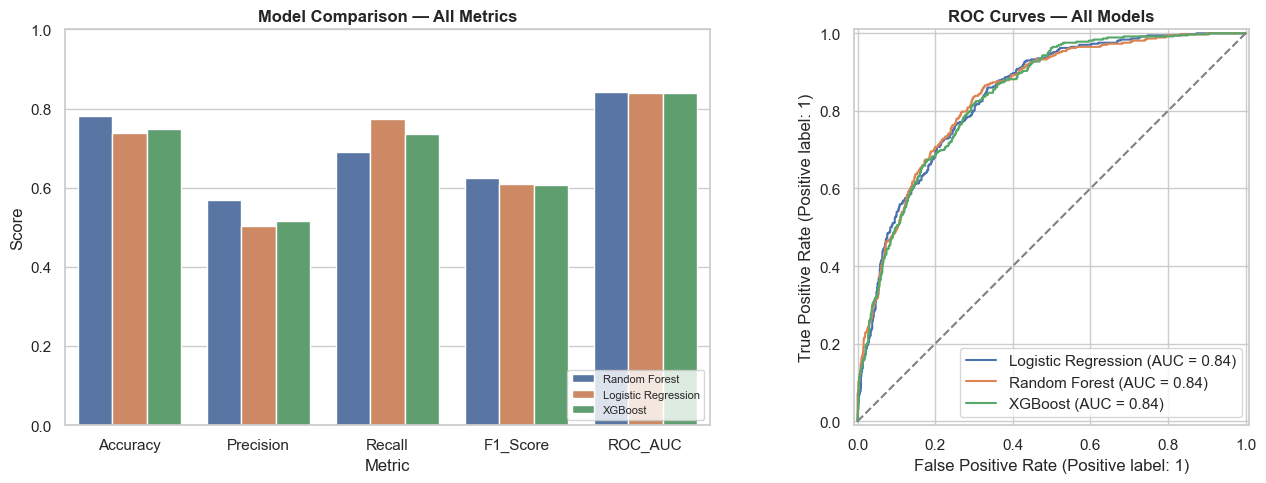

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\08_model_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of all metrics
comparison_melted = comparison_df.melt(
    id_vars="Model",
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model",
    ax=axes[0]
)

axes[0].set_title("Model Comparison — All Metrics", fontweight="bold")
axes[0].set_ylim(0, 1)
axes[0].legend(loc="lower right", fontsize=8)

# ROC curves
RocCurveDisplay.from_predictions(
    y_test,
    log_reg_proba,
    name="Logistic Regression",
    ax=axes[1]
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_proba,
    name="Random Forest",
    ax=axes[1]
)

RocCurveDisplay.from_predictions(
    y_test,
    xgb_proba,
    name="XGBoost",
    ax=axes[1]
)

axes[1].set_title("ROC Curves — All Models", fontweight="bold")
axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Guess"
)

plt.tight_layout()

output_path = FIGURES_DIR / "08_model_comparison.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", output_path)

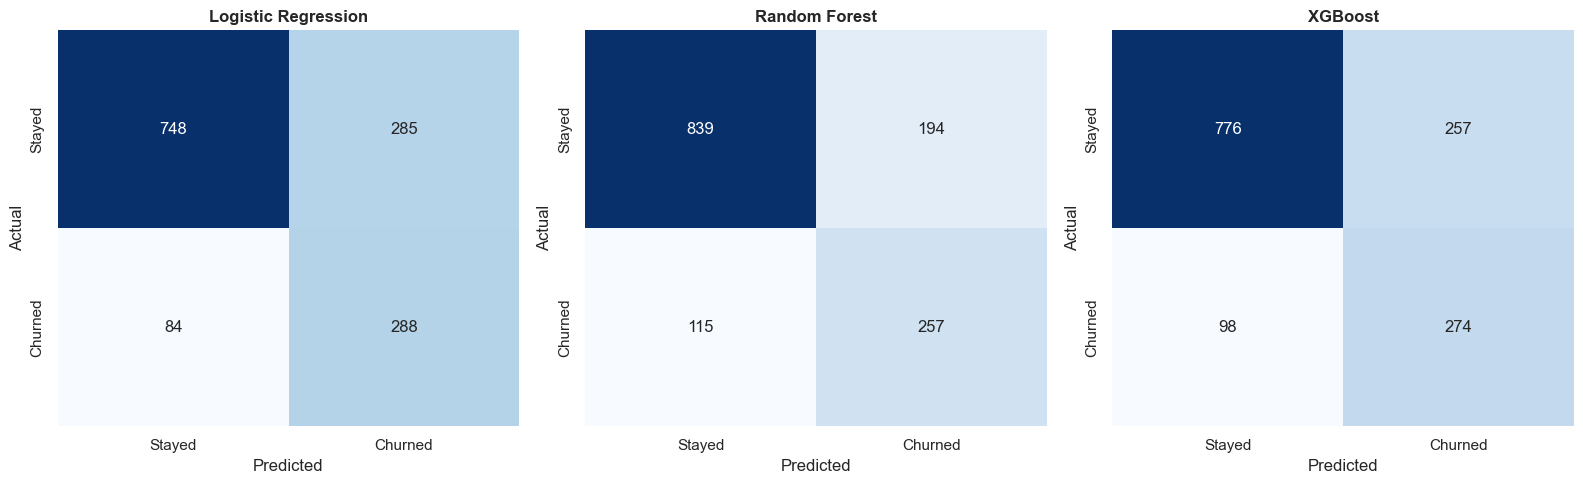

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\09_confusion_matrices.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_preds = [
    ("Logistic Regression", log_reg_pred),
    ("Random Forest", rf_pred),
    ("XGBoost", xgb_pred)
]

for ax, (name, preds) in zip(axes, models_preds):

    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Stayed", "Churned"],
        yticklabels=["Stayed", "Churned"],
        ax=ax,
        cbar=False
    )

    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()

output_path = FIGURES_DIR / "09_confusion_matrices.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", output_path)

In [19]:
best_model_name = comparison_df.iloc[0]["Model"]

print(f"Best model based on ROC-AUC: {best_model_name}")

model_map = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

best_model = model_map[best_model_name]

best_model_path = MODELS_DIR / "churn_model.pkl"

joblib.dump(best_model, best_model_path)

print(f"Best model saved to: {best_model_path}")

Best model based on ROC-AUC: Random Forest
Best model saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\models\churn_model.pkl


In [21]:
joblib.dump(
    log_reg,
    MODELS_DIR / "logistic_regression.pkl"
)

joblib.dump(
    rf_model,
    MODELS_DIR / "random_forest.pkl"
)

joblib.dump(
    xgb_model,
    MODELS_DIR / "xgboost_model.pkl"
)

print("All 3 models saved to models/")

All 3 models saved to models/


In [22]:
comparison_df.to_csv(
    REPORTS_DIR / "model_comparison.csv",
    index=False
)

metrics_dict = comparison_df.to_dict(orient="records")

with open(REPORTS_DIR / "model_metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

print("Metrics saved successfully.")

Metrics saved successfully.


In [23]:
print("========== DAY 7 MODEL CHECK ==========")

print("Best model:", best_model_name)

print("Best model exists:",
      (MODELS_DIR / "churn_model.pkl").exists())

print("Logistic Regression exists:",
      (MODELS_DIR / "logistic_regression.pkl").exists())

print("Random Forest exists:",
      (MODELS_DIR / "random_forest.pkl").exists())

print("XGBoost exists:",
      (MODELS_DIR / "xgboost_model.pkl").exists())

print("Comparison CSV exists:",
      (REPORTS_DIR / "model_comparison.csv").exists())

print("Metrics JSON exists:",
      (REPORTS_DIR / "model_metrics.json").exists())

print("Comparison figure exists:",
      (FIGURES_DIR / "08_model_comparison.png").exists())

print("Confusion matrix figure exists:",
      (FIGURES_DIR / "09_confusion_matrices.png").exists())

========== DAY 7 MODEL CHECK ==========
Best model: Random Forest
Best model exists: True
Logistic Regression exists: True
Random Forest exists: True
XGBoost exists: True
Comparison CSV exists: True
Metrics JSON exists: True
Comparison figure exists: True
Confusion matrix figure exists: True
